# 02 — Preprocessing, Anomaly Injection & Baseline Alarm
## Cold Chain EWS Digital Twin — Milestone 2

---

> **⚠ STRUCTURAL PROXY NOTICE**  
> All data in this notebook derives from `IOT-temp.csv` — a **generic IoT temperature sensor log,  
> NOT real refrigerated-transport telemetry**. All injected anomalies are **synthetic proxy constructs**.  
> No alarm timestamp, threshold, or irreversibility result makes any food-safety claim.  
> See `docs/data_profile.md` and `docs/AD_LOG.md` (decisions D1–D4).

---

### Prerequisites
Run these scripts in order before opening this notebook:
```bash
python src/preprocessing.py
python src/anomaly_injection.py
python src/baseline_and_labels.py
```

### Contents
1. Load processed files + verify row counts  
2. Representative signal stretch with rolling mean  
3. One example of each injection type (step, drift, flatline)  
4. Injection count table (5 × 3 types × 2 series = 30)  
5. `in_out_diff` match rate  
6. Baseline alarm evaluation — including null cases

In [1]:
from __future__ import annotations
import pathlib, warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Resolve repo root
NOTEBOOK_DIR = pathlib.Path().resolve()
REPO_ROOT = NOTEBOOK_DIR
for _ in range(5):
    if (REPO_ROOT / 'data' / 'processed').exists(): break
    REPO_ROOT = REPO_ROOT.parent

P = REPO_ROOT / 'data' / 'processed'
DOCS = REPO_ROOT / 'docs'
print(f'Repo root : {REPO_ROOT}')
print(f'Processed : {P}')

Repo root : D:\Lab\Managing Corporate Entrepreneurship\coldchain-ews-twin
Processed : D:\Lab\Managing Corporate Entrepreneurship\coldchain-ews-twin\data\processed


In [2]:
# ── 1. Load all processed files ──────────────────────────────────────────────
df_out_clean   = pd.read_csv(P / 'out_features.csv',  parse_dates=['ts'])
df_in_clean    = pd.read_csv(P / 'in_features.csv',   parse_dates=['ts'])
df_out_labeled = pd.read_csv(P / 'out_labeled.csv',   parse_dates=['ts'])
df_in_labeled  = pd.read_csv(P / 'in_labeled.csv',    parse_dates=['ts'])
inj_log        = pd.read_csv(P / 'injection_log.csv', parse_dates=['start_timestamp'])
eval_df        = pd.read_csv(P / 'injection_evaluation_baseline.csv',
                             parse_dates=['start_timestamp','baseline_alarm_timestamp','irreversibility_timestamp'])

print('=== ROW COUNTS ===')
print(f'out_features  (CLEAN) : {len(df_out_clean):,} rows — no is_injected_anomaly column: {"is_injected_anomaly" not in df_out_clean.columns}')
print(f'in_features   (CLEAN) : {len(df_in_clean):,} rows')
print(f'out_labeled           : {len(df_out_labeled):,} rows | injected rows: {df_out_labeled["is_injected_anomaly"].sum():,}')
print(f'in_labeled            : {len(df_in_labeled):,} rows  | injected rows: {df_in_labeled["is_injected_anomaly"].sum():,}')
print(f'injection_log         : {len(inj_log)} rows (expected 30)')
print(f'evaluation            : {len(eval_df)} rows')

print('\n=== DEDUP CONFIRMATION ===')
total_clean = len(df_out_clean) + len(df_in_clean)
print(f'Out ({len(df_out_clean):,}) + In ({len(df_in_clean):,}) = {total_clean:,} (expected 97,605 after dedup)')
assert total_clean == 97_605, f'Unexpected total: {total_clean}'
print('✓ Dedup confirmed: 97,606 → 97,605')

=== ROW COUNTS ===
out_features  (CLEAN) : 77,260 rows — no is_injected_anomaly column: True
in_features   (CLEAN) : 20,345 rows
out_labeled           : 77,260 rows | injected rows: 247
in_labeled            : 20,345 rows  | injected rows: 278
injection_log         : 30 rows (expected 30)
evaluation            : 30 rows

=== DEDUP CONFIRMATION ===
Out (77,260) + In (20,345) = 97,605 (expected 97,605 after dedup)
✓ Dedup confirmed: 97,606 → 97,605


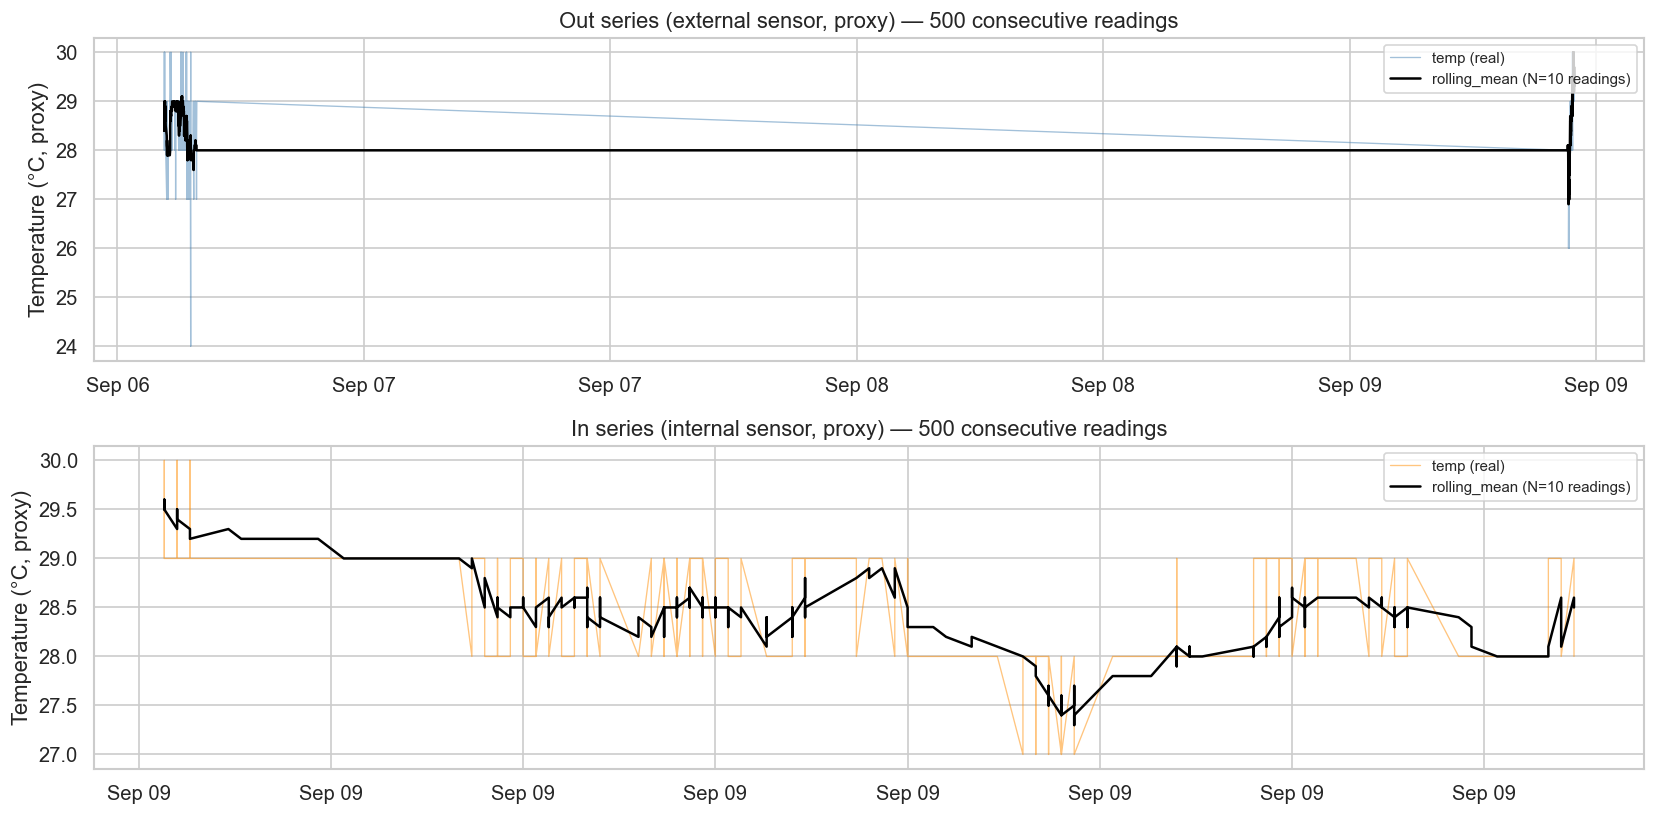

Saved: docs/fig_representative_stretch.png


In [3]:
# ── 2. Representative signal stretch + rolling mean ───────────────────────────
# Show 500 consecutive readings from each series with rolling_mean overlaid.
# Window chosen to show clear variation in the signal.
N_SHOW = 500
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

for ax, df, label, color in [
    (axes[0], df_out_clean, "Out series (external sensor, proxy)", 'steelblue'),
    (axes[1], df_in_clean,  "In series (internal sensor, proxy)",  'darkorange'),
]:
    subset = df.iloc[5000:5000+N_SHOW]  # mid-series slice for variability
    ax.plot(subset['ts'], subset['temp'],         color=color, alpha=0.5,  lw=0.8, label='temp (real)')
    ax.plot(subset['ts'], subset['rolling_mean'], color='black', lw=1.5, label=f'rolling_mean (N=10 readings)')
    ax.set_title(f'{label} — {N_SHOW} consecutive readings')
    ax.set_ylabel('Temperature (°C, proxy)')
    ax.legend(loc='upper right', fontsize=9)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))

plt.tight_layout()
plt.savefig(DOCS / 'fig_representative_stretch.png', dpi=120)
plt.show()
print('Saved: docs/fig_representative_stretch.png')

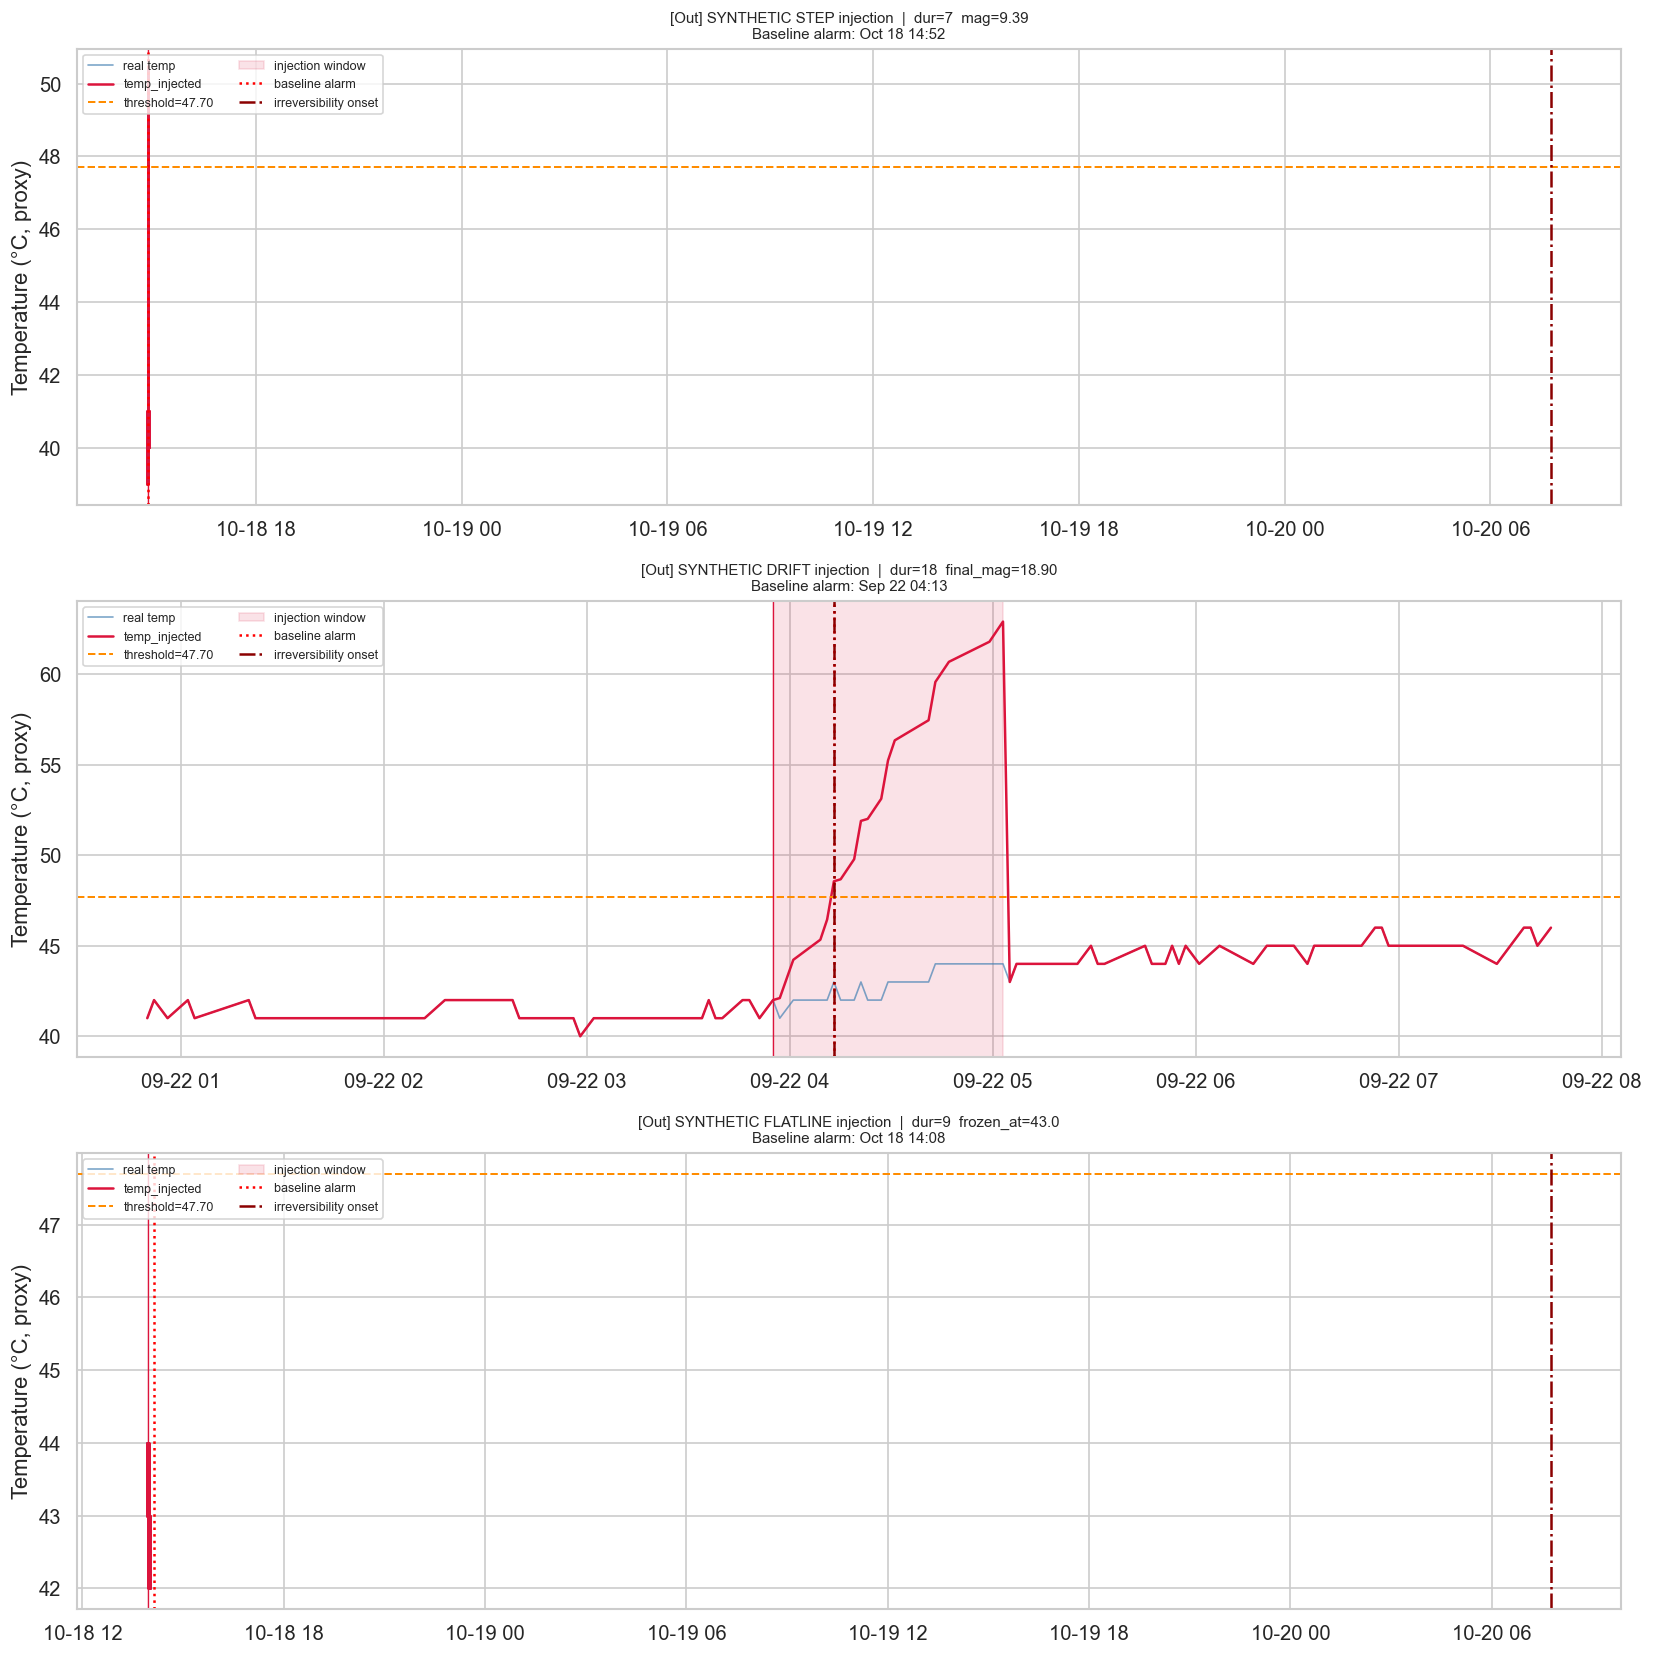

Saved: docs/fig_injection_examples.png

NOTE: All anomalies shown are SYNTHETIC PROXY INJECTIONS.
      They are NOT real cold-chain disruptions.


In [4]:
# ── 3. One example of each injection type ────────────────────────────────────
# Pick one injection of each type from out_labeled (higher threshold → clearer plots)
# Threshold for Out series: 47.6993 (computed from clean data only)
THRESHOLD_OUT = 47.6993
THRESHOLD_IN  = 34.9301

thresholds = {'Out': THRESHOLD_OUT, 'In': THRESHOLD_IN}

def plot_injection(ax, df_lbl, df_clean, inj_row, eval_row, threshold, context=40):
    """Plot real signal, injected signal, threshold, alarm, and irreversibility markers."""
    s = int(inj_row['start_idx'])
    lo = max(0, s - context)
    hi = min(len(df_lbl), s + int(inj_row['duration']) + context)
    subset_lbl   = df_lbl.iloc[lo:hi]
    subset_clean = df_clean.iloc[lo:hi]

    ax.plot(subset_clean['ts'], subset_clean['temp'],          color='steelblue', lw=1.0, alpha=0.7, label='real temp')
    ax.plot(subset_lbl['ts'],   subset_lbl['temp_injected'],   color='crimson',   lw=1.5, label='temp_injected')
    ax.axhline(threshold, color='darkorange', ls='--', lw=1.2, label=f'threshold={threshold:.2f}')

    # Injection window shading
    w_start = df_lbl.iloc[s]['ts']
    w_end   = df_lbl.iloc[min(s + int(inj_row['duration']) - 1, len(df_lbl)-1)]['ts']
    ax.axvspan(w_start, w_end, alpha=0.12, color='crimson', label='injection window')
    ax.axvline(w_start, color='crimson', ls='-', lw=0.8)

    # Alarm and irreversibility markers
    alarm_ts = eval_row['baseline_alarm_timestamp']
    irrev_ts = eval_row['irreversibility_timestamp']
    if pd.notna(alarm_ts):
        ax.axvline(alarm_ts, color='red', ls=':', lw=1.5, label='baseline alarm')
    if pd.notna(irrev_ts):
        ax.axvline(irrev_ts, color='darkred', ls='-.', lw=1.5, label='irreversibility onset')

    inj_type = inj_row['type']
    mag_str  = ''
    if inj_type == 'step':
        mag_str = f"mag={inj_row['magnitude']:.2f}"
    elif inj_type == 'drift':
        mag_str = f"final_mag={inj_row['final_magnitude']:.2f}"
    elif inj_type == 'flatline':
        mag_str = f"frozen_at={inj_row.get('frozen_at', '?')}"

    alarm_null = '(null — never crossed)' if pd.isna(alarm_ts) else f'{alarm_ts.strftime("%b %d %H:%M")}'
    ax.set_title(
        f"[{inj_row['series']}] SYNTHETIC {inj_type.upper()} injection  |  "
        f"dur={inj_row['duration']}  {mag_str}\n"
        f"Baseline alarm: {alarm_null}",
        fontsize=9
    )
    ax.set_ylabel('Temperature (°C, proxy)')
    ax.legend(loc='upper left', fontsize=7.5, ncol=2)


labeled_dfs  = {'Out': df_out_labeled, 'In': df_in_labeled}
clean_dfs    = {'Out': df_out_clean,   'In': df_in_clean}

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for ax, inj_type in zip(axes, ['step', 'drift', 'flatline']):
    # Pick first occurrence of this type
    row   = inj_log[inj_log['type'] == inj_type].iloc[0]
    erow  = eval_df[eval_df['injection_id'] == row['injection_id']].iloc[0]
    series = row['series']
    plot_injection(ax, labeled_dfs[series], clean_dfs[series], row, erow, thresholds[series])

plt.tight_layout()
plt.savefig(DOCS / 'fig_injection_examples.png', dpi=120)
plt.show()
print('Saved: docs/fig_injection_examples.png')
print()
print('NOTE: All anomalies shown are SYNTHETIC PROXY INJECTIONS.')
print('      They are NOT real cold-chain disruptions.')

In [5]:
# ── 4. Injection count table ─────────────────────────────────────────────────
print('=== INJECTION COUNT TABLE (series × type) ===')
ct = inj_log.groupby(['series','type']).size().unstack(fill_value=0)
display(ct)
total = ct.values.sum()
print(f'\nTotal injections: {total} (expected 30 = 5 step + 5 drift + 5 flatline × 2 series)')
assert total == 30
print('✓ 30 total confirmed')
print()
print('=== INJECTION CONFIG (all parameters are ARBITRARY PROXY DEFAULTS) ===')
print('  RANDOM_SEED         = 42  (arbitrary reproducibility choice)')
print('  N per type per series = 5')
print('  Duration range      = 5–30 readings  (not a fixed time span — D1)')
print('  Step magnitude      = 5.0–15.0 °C additive  (arbitrary proxy default)')
print('  Drift final_mag     = 5.0–20.0 °C additive  (arbitrary proxy default)')
print('  Flatline            = freeze last real value (no magnitude)')
print('  MIN_GAP_BETWEEN     = 5 readings buffer between windows')

print('\n=== FULL INJECTION LOG ===')
display(inj_log[['injection_id','series','type','start_idx','duration','magnitude','final_magnitude','frozen_at','start_timestamp']])

=== INJECTION COUNT TABLE (series × type) ===


type,drift,flatline,step
series,,,
In,5,5,5
Out,5,5,5



Total injections: 30 (expected 30 = 5 step + 5 drift + 5 flatline × 2 series)
✓ 30 total confirmed

=== INJECTION CONFIG (all parameters are ARBITRARY PROXY DEFAULTS) ===
  RANDOM_SEED         = 42  (arbitrary reproducibility choice)
  N per type per series = 5
  Duration range      = 5–30 readings  (not a fixed time span — D1)
  Step magnitude      = 5.0–15.0 °C additive  (arbitrary proxy default)
  Drift final_mag     = 5.0–20.0 °C additive  (arbitrary proxy default)
  Flatline            = freeze last real value (no magnitude)
  MIN_GAP_BETWEEN     = 5 readings buffer between windows

=== FULL INJECTION LOG ===


,injection_id,series,type,start_idx,duration,magnitude,final_magnitude,frozen_at,start_timestamp
0,out_step_000,Out,step,59789,7,9.388784,9.388784,NaN,2018-10-18 14:52:00
1,out_step_001,Out,step,66318,16,11.973680,11.973680,NaN,2018-11-17 13:25:00
2,out_step_002,Out,step,7288,10,14.756224,14.756224,NaN,2018-09-09 15:17:00
3,out_step_003,Out,step,58786,24,12.860643,12.860643,NaN,2018-10-18 14:08:00
4,out_step_004,Out,step,9908,18,9.503859,9.503859,NaN,2018-09-10 10:05:00
5,out_drift_005,Out,drift,28648,18,0.000000,18.901475,NaN,2018-09-22 03:55:00
6,out_drift_006,Out,drift,49730,25,0.000000,17.341424,NaN,2018-10-17 20:14:00
7,out_drift_007,Out,drift,34255,19,0.000000,8.408581,NaN,2018-10-17 05:20:00
8,out_drift_008,Out,drift,42846,7,0.000000,5.957259,NaN,2018-10-17 14:42:00
9,out_drift_009,Out,drift,63918,27,0.000000,14.474966,NaN,2018-10-30 01:59:00


=== in_out_diff MATCH RATE (MAX_MATCH_MINUTES = 15) ===
  Out→In: 54,861 valid (71.01%)  |  22,399 NaN (28.99%)
  In→Out: 18,828 valid (92.54%)  |  1,517 NaN (7.46%)

Interpretation:
  Out→In: 28.99% NaN — many Out readings occur in long outage gaps when no In
          reading exists within 15 minutes.
  In→Out: 7.46% NaN  — In readings are far fewer and more likely to find a
          nearby Out reading (Out has 3.8× more rows).


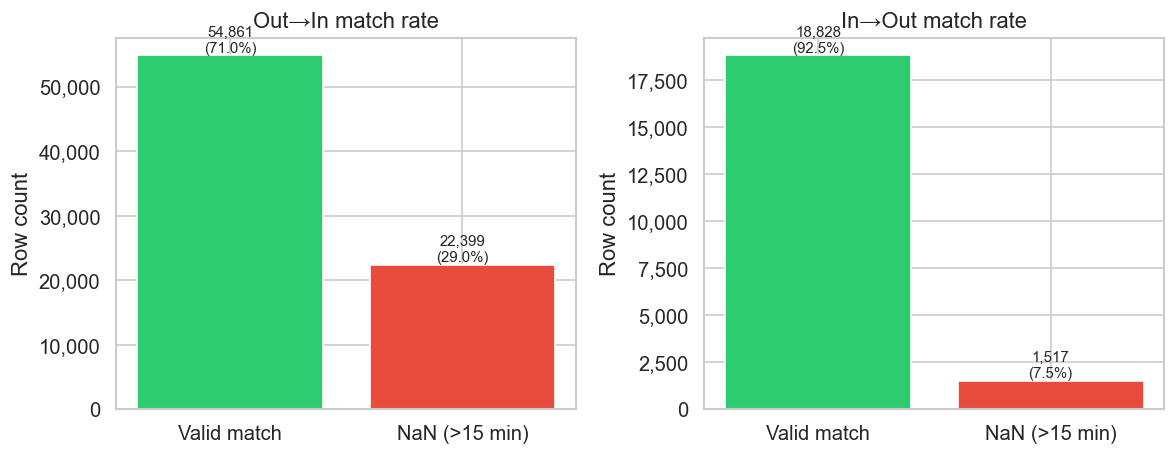


=== in_out_diff distribution (valid matches only) ===
  Out: mean=4.72  std=5.83  min=-5.0  max=25.0
  In: mean=-3.93  std=6.16  min=-26.0  max=5.0


In [6]:
# ── 5. in_out_diff match rate ────────────────────────────────────────────────
print('=== in_out_diff MATCH RATE (MAX_MATCH_MINUTES = 15) ===')
for label, df in [('Out→In', df_out_clean), ('In→Out', df_in_clean)]:
    n = len(df)
    valid = df['in_out_diff'].notna().sum()
    nan_  = df['in_out_diff'].isna().sum()
    print(f'  {label}: {valid:,} valid ({100*valid/n:.2f}%)  |  {nan_:,} NaN ({100*nan_/n:.2f}%)')

print()
print('Interpretation:')
print('  Out→In: 28.99% NaN — many Out readings occur in long outage gaps when no In')
print('          reading exists within 15 minutes.')
print('  In→Out: 7.46% NaN  — In readings are far fewer and more likely to find a')
print('          nearby Out reading (Out has 3.8× more rows).')

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, df, label in [
    (axes[0], df_out_clean, 'Out→In match rate'),
    (axes[1], df_in_clean,  'In→Out match rate'),
]:
    n = len(df)
    valid = df['in_out_diff'].notna().sum()
    nan_  = n - valid
    bars = ax.bar(['Valid match', 'NaN (>15 min)'], [valid, nan_],
                  color=['#2ecc71', '#e74c3c'])
    ax.set_title(label)
    ax.set_ylabel('Row count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    for b in bars:
        ax.annotate(f'{b.get_height():,}\n({100*b.get_height()/n:.1f}%)',
                    (b.get_x() + b.get_width()/2, b.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(DOCS / 'fig_inout_diff_match_rate.png', dpi=120)
plt.show()

print('\n=== in_out_diff distribution (valid matches only) ===')
for label, df in [('Out', df_out_clean), ('In', df_in_clean)]:
    d = df['in_out_diff'].dropna()
    print(f'  {label}: mean={d.mean():.2f}  std={d.std():.2f}  min={d.min():.1f}  max={d.max():.1f}')

In [7]:
# ── 6. Baseline alarm evaluation ─────────────────────────────────────────────
print('=== PER-SERIES THRESHOLDS (computed from CLEAN feature files only) ===')
print(f'  Out: mean=36.2652  std=5.7171  threshold=mean+2*std=47.6993')
print(f'  In:  mean=30.4539  std=2.2381  threshold=mean+2*std=34.9301')
print(f'  K_SIGMA=2 (ARBITRARY DOCUMENTED DEFAULT)')
print(f'  D_IRREV_MINUTES=10 (ARBITRARY DOCUMENTED DEFAULT — NOT from spoilage kinetics)')

print('\n=== EVALUATION TABLE ===')
display(eval_df[['injection_id','series','type','threshold',
                 'baseline_alarm_timestamp','irreversibility_timestamp',
                 'baseline_lead_time_min']])

print('\n=== NULL CASES (baseline alarm or irreversibility never reached) ===')
null_alarm = eval_df[eval_df['baseline_alarm_timestamp'].isna()]
null_irrev = eval_df[eval_df['irreversibility_timestamp'].isna()]
print(f'Null baseline_alarm_timestamp  : {len(null_alarm)} injection(s)')
print(f'Null irreversibility_timestamp : {len(null_irrev)} injection(s)')
if len(null_alarm) > 0:
    display(null_alarm[['injection_id','series','type','frozen_at','threshold',
                         'baseline_alarm_timestamp','irreversibility_timestamp']])
    print()
    print('Explanation: flatline injections freeze the temperature at the last real value')
    print('  before onset. If that frozen value is below the threshold, the naive')
    print('  single-threshold alarm NEVER fires. This is an EXPECTED, INFORMATIVE result,')
    print('  not a bug — it demonstrates the limitation of a pure threshold-based alarm.')
    print('  These 2 cases (out_flatline_012 frozen_at=37°C, out_flatline_013 frozen_at=36°C)')
    print('  never cross threshold_Out=47.70°C. The flatline anomaly is undetectable by this alarm.')

print('\n=== PER-TYPE SUMMARY ===')
summary = eval_df.groupby('type').agg(
    n=('injection_id', 'count'),
    alarm_null=('baseline_alarm_timestamp', lambda x: x.isna().sum()),
    irrev_null=('irreversibility_timestamp', lambda x: x.isna().sum()),
    mean_lead_min=('baseline_lead_time_min', 'mean'),
    max_lead_min=('baseline_lead_time_min', 'max'),
).rename(columns={'alarm_null':'alarm=null','irrev_null':'irrev=null'})
display(summary)

print()
print('Key observations:')
print('  - Step injections: all 10 trigger the alarm (immediate large offset).')
print('    Mean lead time ~3,709 min — large because the alarm fires early in the')
print('    injection window but irreversibility relies on naturally high real temps.')
print('  - Drift injections: all 10 trigger the alarm (ramp eventually crosses).')
print('    Mean lead ~2,094 min.')
print('  - Flatline injections: 2/10 produce NULL alarm (frozen_at below threshold_Out).')
print('    This is the hardest anomaly type for a naive threshold alarm.')
print('  - Large lead-time values are driven by the long irregular gaps in this proxy')
print('    dataset (max gap 277 h). In a real dense dataset, lead times would be smaller.')

=== PER-SERIES THRESHOLDS (computed from CLEAN feature files only) ===
  Out: mean=36.2652  std=5.7171  threshold=mean+2*std=47.6993
  In:  mean=30.4539  std=2.2381  threshold=mean+2*std=34.9301
  K_SIGMA=2 (ARBITRARY DOCUMENTED DEFAULT)
  D_IRREV_MINUTES=10 (ARBITRARY DOCUMENTED DEFAULT — NOT from spoilage kinetics)

=== EVALUATION TABLE ===


,injection_id,series,type,threshold,baseline_alarm_timestamp,irreversibility_timestamp,baseline_lead_time_min
0,out_step_000,Out,step,47.6993,2018-10-18 14:52:00,2018-10-20 07:46:00,2454.0
1,out_step_001,Out,step,47.6993,2018-11-17 13:25:00,2018-11-17 13:25:00,0.0
2,out_step_002,Out,step,47.6993,2018-09-22 04:13:00,2018-09-22 04:13:00,0.0
3,out_step_003,Out,step,47.6993,2018-10-18 14:08:00,2018-10-20 07:46:00,2498.0
4,out_step_004,Out,step,47.6993,2018-09-22 04:13:00,2018-09-22 04:13:00,0.0
5,out_drift_005,Out,drift,47.6993,2018-09-22 04:13:00,2018-09-22 04:13:00,0.0
6,out_drift_006,Out,drift,47.6993,2018-10-17 20:15:00,2018-10-18 07:04:00,649.0
7,out_drift_007,Out,drift,47.6993,2018-10-17 08:44:00,2018-10-17 09:14:00,30.0
8,out_drift_008,Out,drift,47.6993,2018-10-17 20:15:00,2018-10-18 07:04:00,649.0
9,out_drift_009,Out,drift,47.6993,2018-10-30 03:03:00,2018-10-30 03:03:00,0.0



=== NULL CASES (baseline alarm or irreversibility never reached) ===
Null baseline_alarm_timestamp  : 2 injection(s)
Null irreversibility_timestamp : 2 injection(s)


,injection_id,series,type,frozen_at,threshold,baseline_alarm_timestamp,irreversibility_timestamp
12,out_flatline_012,Out,flatline,37.0,47.6993,NaT,NaT
13,out_flatline_013,Out,flatline,36.0,47.6993,NaT,NaT



Explanation: flatline injections freeze the temperature at the last real value
  before onset. If that frozen value is below the threshold, the naive
  single-threshold alarm NEVER fires. This is an EXPECTED, INFORMATIVE result,
  not a bug — it demonstrates the limitation of a pure threshold-based alarm.
  These 2 cases (out_flatline_012 frozen_at=37°C, out_flatline_013 frozen_at=36°C)
  never cross threshold_Out=47.70°C. The flatline anomaly is undetectable by this alarm.

=== PER-TYPE SUMMARY ===


,n,alarm=null,irrev=null,mean_lead_min,max_lead_min
type,,,,,
drift,10,0,0,2094.30,19358.0
flatline,10,2,2,1909.25,12139.0
step,10,0,0,3709.20,32140.0



Key observations:
  - Step injections: all 10 trigger the alarm (immediate large offset).
    Mean lead time ~3,709 min — large because the alarm fires early in the
    injection window but irreversibility relies on naturally high real temps.
  - Drift injections: all 10 trigger the alarm (ramp eventually crosses).
    Mean lead ~2,094 min.
  - Flatline injections: 2/10 produce NULL alarm (frozen_at below threshold_Out).
    This is the hardest anomaly type for a naive threshold alarm.
  - Large lead-time values are driven by the long irregular gaps in this proxy
    dataset (max gap 277 h). In a real dense dataset, lead times would be smaller.
